In [1]:
from shutil import ignore_patterns
import pyarrow.dataset as ds

dataset = ds.dataset(
    "/hits/basement/its/doserbd/data/SKIRT_synthetic_images_small/parquet-128/",
    format="parquet",
    exclude_invalid_files=True,
)
print(dataset.count_rows())
dataset.schema

200


data: list<element: double>
  child 0, element: double
simulation: string
snapshot: string
subhalo_id: string
-- schema metadata --
data_shape: '(3, 128, 128)'

In [2]:
df = dataset.to_table().to_pandas()

/tmp/ipykernel_179138/1468233574.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(data.astype(np.uint8), "RGB")


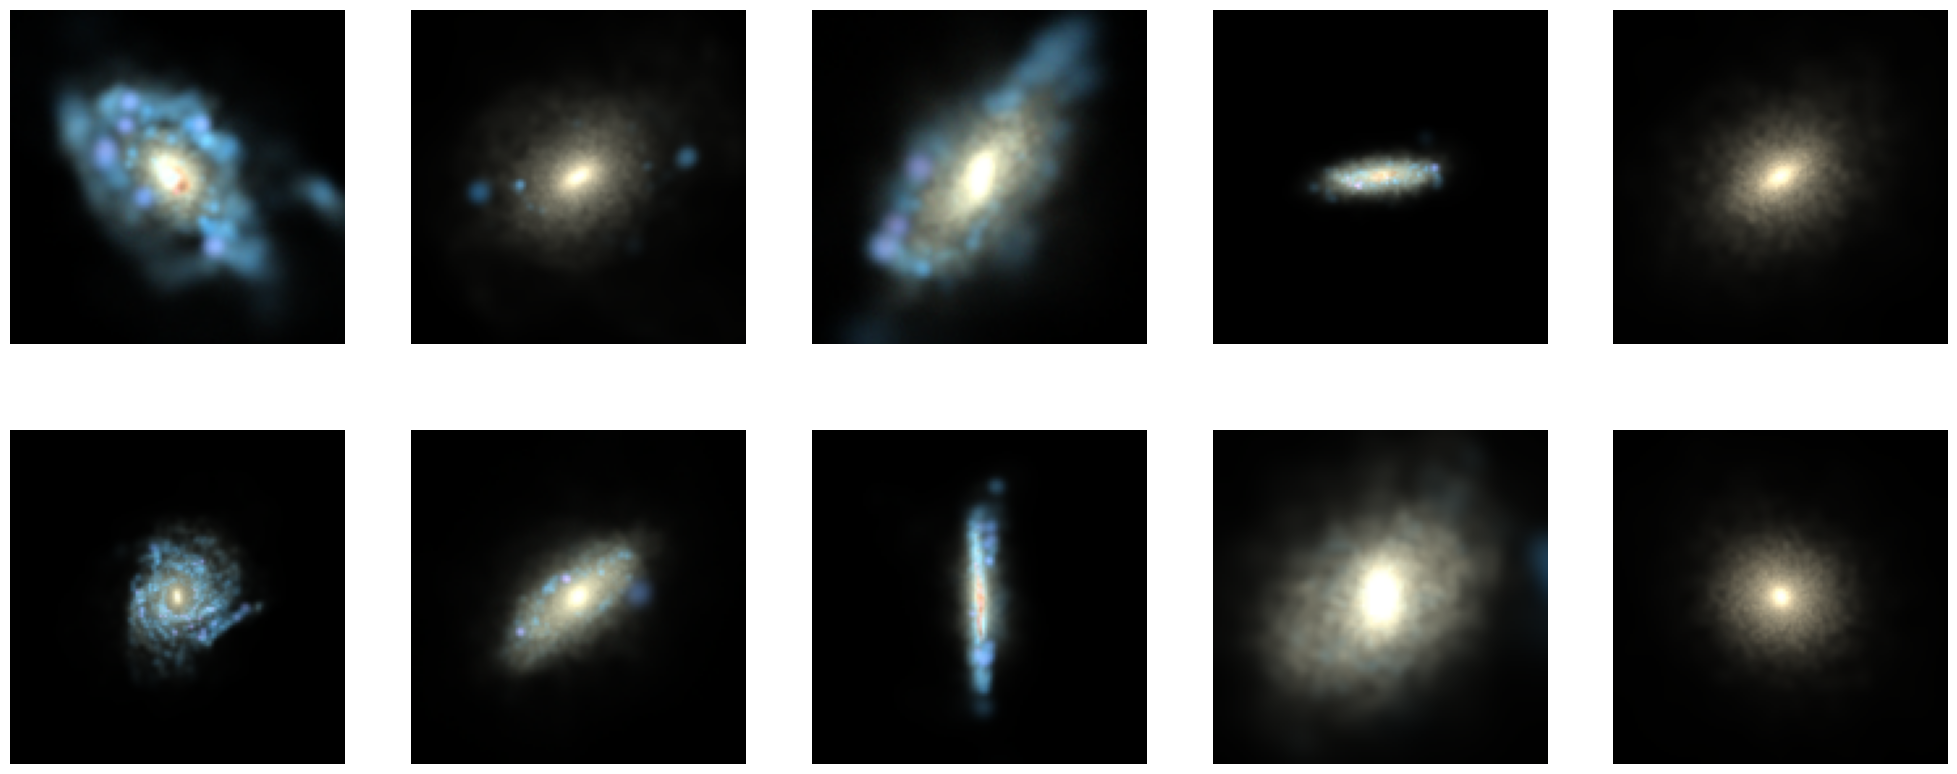

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
for i, ax in enumerate(axes.flatten()):
    data = np.array(df["data"][i]).reshape(3, 128, 128).transpose(1, 2, 0) * 255
    image = Image.fromarray(data.astype(np.uint8), "RGB")
    ax.imshow(image)
    ax.axis("off")
plt.show()

In [4]:
from PIL import Image
import numpy as np
import os

# Create images directory if it doesn't exist
os.makedirs("images/train", exist_ok=True)

for index, row in df.iterrows():
    data = np.array(row["data"]).reshape(3, 128, 128).transpose(1, 2, 0) * 255
    image = Image.fromarray(data.astype(np.uint8), "RGB")
    image.save(f"images/train/{row['subhalo_id']}.png")

/tmp/ipykernel_179138/2563733682.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(data.astype(np.uint8), "RGB")


In [7]:
from datasets import load_dataset

dataset = load_dataset("imagefolder", data_dir="images/train", split="train")
dataset.push_to_hub("bernddoser/Illustris_TNG_SKIRT_SDSS")

Uploading the dataset shards: 100%|██████████| 1/1 [00:02<00:00,  2.01s/ shards]


CommitInfo(commit_url='https://huggingface.co/datasets/bernddoser/Illustris_TNG_SKIRT_SDSS/commit/70e3ce0ac3e0880c193eed969bf5f9ddb6241a27', commit_message='Upload dataset', commit_description='', oid='70e3ce0ac3e0880c193eed969bf5f9ddb6241a27', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/bernddoser/Illustris_TNG_SKIRT_SDSS', endpoint='https://huggingface.co', repo_type='dataset', repo_id='bernddoser/Illustris_TNG_SKIRT_SDSS'), pr_revision=None, pr_num=None)